In [631]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [632]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [633]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN rtParent.title like '% Swipe' and smt.group_id is not null THEN rtParent.title ELSE 'No Gesture' END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title like '% Swipe' and smt.group_id is not null THEN 1 ELSE 0 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
WHERE is_gesture = 1
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [634]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [635]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [636]:
# Augment the data in a way, that you copy all rows with their columns, only change the order of the touch_X_* columns randomly, also append a unique suffix to the id fields, group_id, session_task_id, participant_id, so that they are unique in the new dataset
def augment_data(df, n_augmentations=1):
    augmented_dfs = []
    
    for i in range(n_augmentations):
        df_aug = df.copy()
        
        # Shuffle touch columns
        shuffled_indices = np.random.permutation(5) + 1  # Touch indices from 1 to 5
        for j, new_idx in enumerate(shuffled_indices, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']
        
        # Append unique suffix to id fields
        df_aug['id'] = df_aug['id'].astype(str) + f'_aug{i}'
        df_aug['group_id'] = df_aug['group_id'].astype(str) + f'_aug{i}'
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + f'_aug{i}'
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + f'_aug{i}'
        
        augmented_dfs.append(df_aug)
    
    return pd.concat([df] + augmented_dfs, ignore_index=True)

def augment_data_all_permutations(df, limit=None):
    augmented_dfs = []

    # All 5! = 120 permutations of touch indices 1..5
    permutations = list(itertools.permutations(range(1, 6)))

    for i, perm in enumerate(permutations):
        if limit is not None and i >= limit:
            break

        df_aug = df.copy()

        # Reorder touch columns according to permutation
        for j, new_idx in enumerate(perm, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']

        # Append unique suffix to id fields
        suffix = f'_perm{i}'
        df_aug['id'] = df_aug['id'].astype(str) + suffix
        df_aug['group_id'] = df_aug['group_id'].astype(str) + suffix
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + suffix
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + suffix

        augmented_dfs.append(df_aug)

    # Original + all permutations
    return pd.concat([df] + augmented_dfs, ignore_index=True)

In [637]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [638]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
Pinch Swipe     12037
Spread Swipe     9049
Single Swipe     6072
Name: count, dtype: int64

In [639]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [640]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    2469
6331fbd1-76bb-48d6-92a2-80a55a70d134    3298
696b4743-9d39-4fb1-8271-90e7d48652af    2738
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    3756
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    4027
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    3322
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    4079
fdd02af8-c764-43ba-8247-c612f85568b4    3469
dtype: int64

In [641]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel']

In [642]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

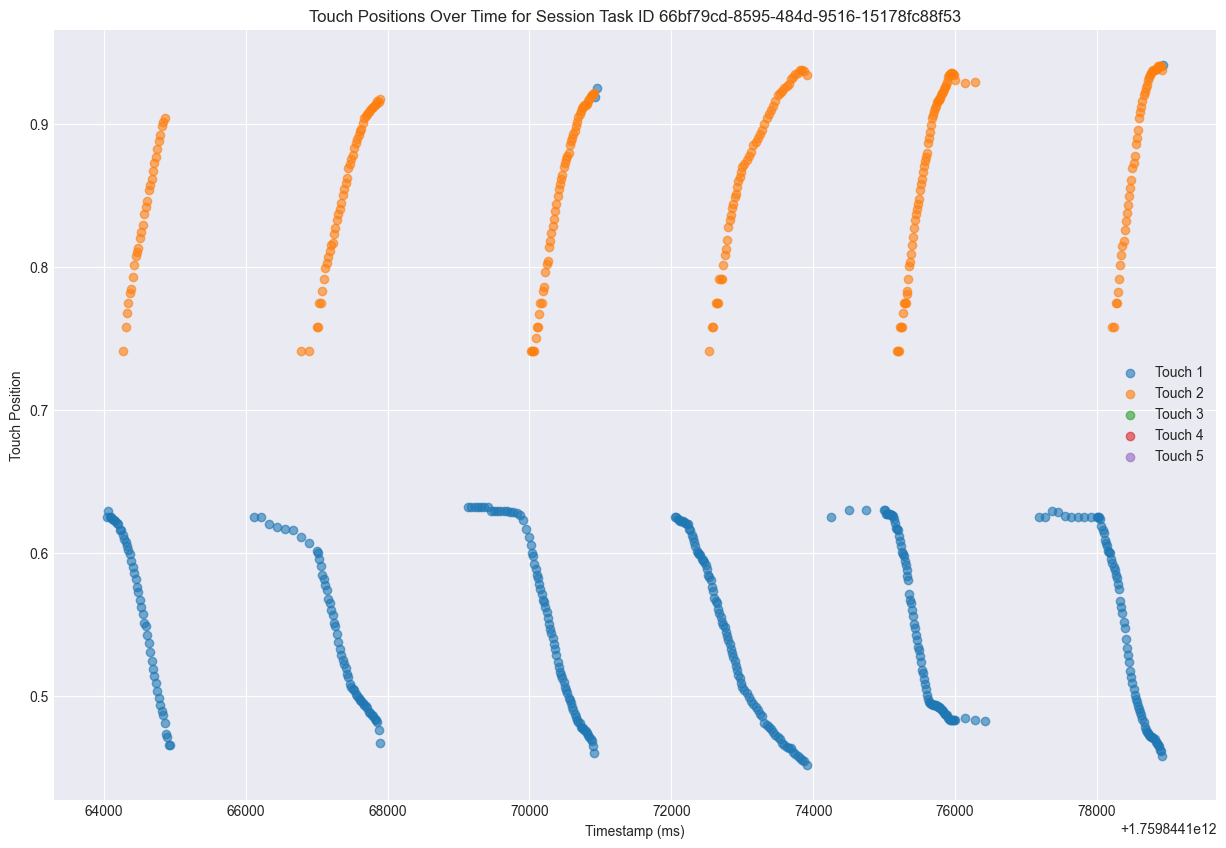

In [643]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [644]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


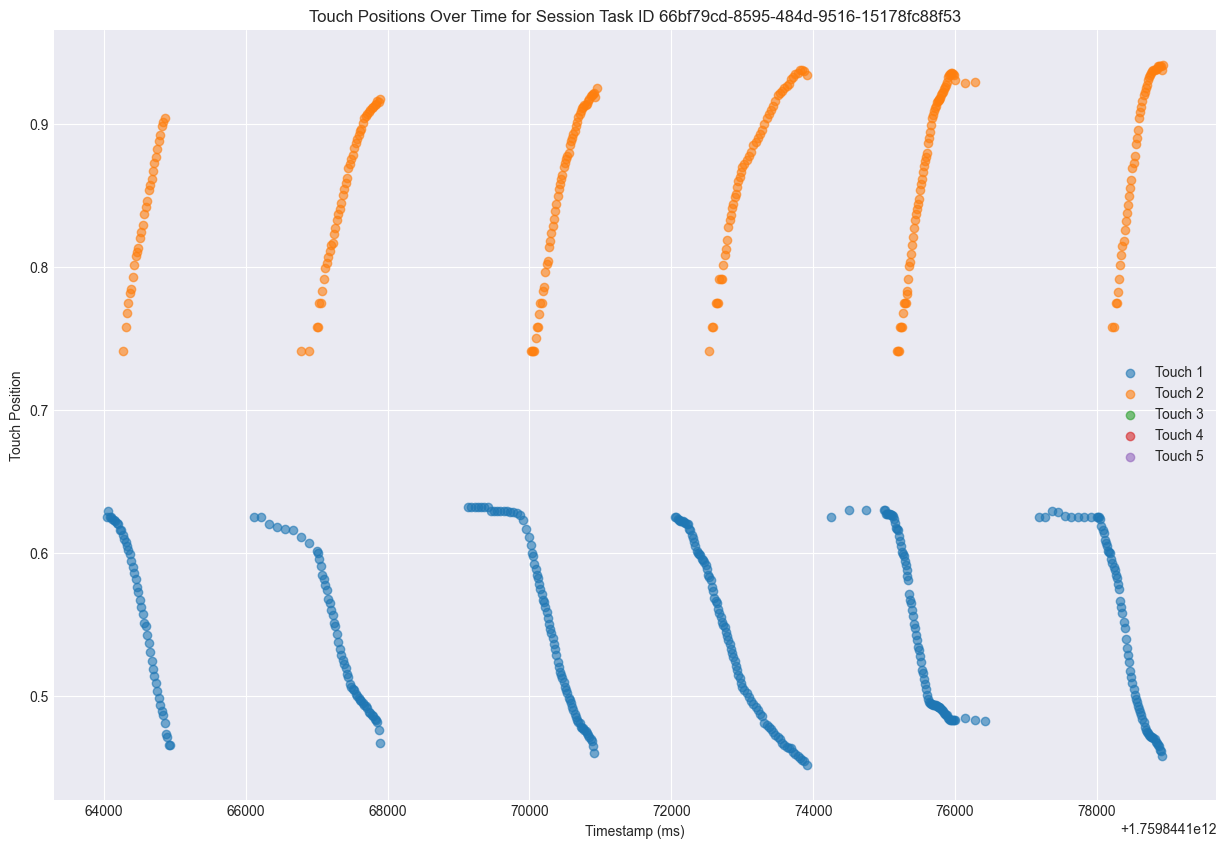

In [645]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [646]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
dtype: int64

In [647]:
# Print the LABEL_COLUMN counts
print(df_clean[LABEL_COLUMN].value_counts())

parent_gesture
Pinch Swipe     12037
Spread Swipe     9049
Single Swipe     6072
Name: count, dtype: int64


In [648]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=5, long_smoothing_window=20):
    # Create empty feature dataframe
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    # Instant Features
    pressure_cols = [f"touch_{i+1}_pressure" for i in range(5)]
    active_touches = (feature_df[pressure_cols] > 0)
    # add_feature("num_active_touches", active_touches.sum(axis=1))

    # Calculate the total number of moving fingers
    def is_moving(position_series):
        pos_diff = position_series.diff().fillna(0)
        time_diff = feature_df[TIMESTAMP_COLUMN].diff().fillna(1) / 1000.0
        velocity = pos_diff / time_diff
        moving = velocity.abs() > TOUCH_MOVE_THRESHOLD
        return moving
    moving_fingers = pd.DataFrame()
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        moving_fingers[f'touch_{touch_num}_is_moving'] = is_moving(feature_df[position_col])
    add_feature("num_moving_fingers", moving_fingers.sum(axis=1))

    # Distances for each finger in the rolling window to each other finger
    for (i, j) in combinations(range(1, 6), 2):
        pos_i = feature_df[f'touch_{i}_position']
        pos_j = feature_df[f'touch_{j}_position']
        p_i = feature_df[f"touch_{i}_pressure"]
        p_j = feature_df[f"touch_{j}_pressure"]

        # distance only when both fingers are active; else 0 (or np.nan if you prefer)
        dist_col = f"dist_{i}_{j}"
        dist = short_dist(pos_i, pos_j)
        both_touching = (p_i > 0) & (p_j > 0)
        add_feature(dist_col, dist)
        # Add min and max dist over long window
        long_min_dist = dist.rolling(window=long_smoothing_window, min_periods=1).min()
        long_max_dist = dist.rolling(window=long_smoothing_window, min_periods=1).max()
        # add_feature(f"{dist_col}_long_min", long_min_dist)
        # add_feature(f"{dist_col}_long_max", long_max_dist)
        # add_feature(f"{dist_col}_both_touching", both_touching.astype(int))

        # Calculate distance velocity
        dist_diff = dist.diff().fillna(0)
        time_diff = feature_df[TIMESTAMP_COLUMN].diff().fillna(1) / 1000.0  # convert ms to s
        dist_velocity = dist_diff / time_diff
        # add_feature(f"{dist_col}_velocity", dist_velocity)

        # Calculate a flag if both fingers are active in the long smoothing window
        # long_both_touching = both_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f"{dist_col}_long_both_active", long_both_touching.astype(int))

        # Calculate a flag if both have moved
        # min_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_i = (max_long_rolling_i - min_long_rolling_i) > TOUCH_MOVE_THRESHOLD
        # min_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_j = (max_long_rolling_j - min_long_rolling_j) > TOUCH_MOVE_THRESHOLD
        # both_moved = has_moved_i & has_moved_j
        # add_feature(f"{dist_col}_both_moved_longterm", both_moved.astype(int))

    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        # velocity calculation
        pos_diff = feature_df[position_col].diff().fillna(0)
        time_diff = feature_df[TIMESTAMP_COLUMN].diff().fillna(1) / 1000.0  # convert ms to s
        velocity = pos_diff / time_diff
        add_feature(f'touch_{touch_num}_position_velocity', velocity.rolling(window=smoothing_window, min_periods=1).mean())

        # split to rotational position into x and y components for smoothing
        # add_feature(f'touch_{touch_num}_pos_x', np.cos(2 * np.pi * feature_df[position_col]))
        # add_feature(f'touch_{touch_num}_pos_y', np.sin(2 * np.pi * feature_df[position_col]))

        # Get the min and max distance to all other fingers
        other_positions = [f'touch_{i}_position' for i in range(1, 6) if i != touch_num]
        if other_positions:
            for other_pos_col in other_positions:
                dist_to_other = short_dist(feature_df[position_col], feature_df[other_pos_col])
                # add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}', dist_to_other)
                # Calculate velocity of distance to other finger
                dist_diff = dist_to_other.diff().fillna(0)
                dist_velocity = dist_diff / time_diff
                # add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}_velocity', dist_velocity)

        is_touching = (feature_df[pressure_col] > 0)
        # add_feature(f'touch_{touch_num}_is_active', is_touching.astype(int))
        is_active_smoothed = is_touching.rolling(window=smoothing_window, min_periods=1).mean()
        # add_feature(f'touch_{touch_num}_is_active_smoothed', is_active_smoothed)

        # Add a flag, whether a finger touched and released and touched again in the smoothing window
        reactivation = (~is_touching.shift(1, fill_value=False)) & is_touching
        touch_before = is_touching.rolling(smoothing_window).max().astype(bool)
        reactivation_in_window = reactivation.rolling(smoothing_window).max().astype(bool)
        has_reactivated = (touch_before & reactivation_in_window)
        # add_feature(f'touch_{touch_num}_has_reactivated', has_reactivated.astype(int))

        min_long_rolling_pos = feature_df[position_col].rolling(window=smoothing_window, min_periods=1).min()
        max_long_rolling_pos = feature_df[position_col].rolling(window=smoothing_window, min_periods=1).max()
        has_moved = (max_long_rolling_pos - min_long_rolling_pos) > TOUCH_MOVE_THRESHOLD
        add_feature(f'touch_{touch_num}_has_moved_longterm', has_moved.astype(int))

        long_touch = is_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f'touch_{touch_num}_long_touch', long_touch.astype(int))

        # Add flag if the touch is active or not, it is active if np.any(is_touching) and (has_moved or not is_continuous_touch)
        is_active_touch = is_touching & (has_moved | (~long_touch))
        # add_feature(f'touch_{touch_num}_is_active_touch', is_active_touch.astype(int))

        # add_feature(f'{position_col}_mean', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        # add_feature(f'{pressure_col}_mean', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        # add_feature(f'{channel_col}_mean', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        # add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        # add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        
        # add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        # add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        # add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))

    # add_feature("num_active_touches_mean", feature_df["num_active_touches"]
            # .rolling(window=smoothing_window, min_periods=1)
            # .mean())
    # add_feature("num_active_touches_max", feature_df["num_active_touches"]
            # .rolling(window=smoothing_window, min_periods=1)
            # .max())
    # active_touches_contrast = active_touches - active_touches.rolling(window=2, min_periods=1).median()
    # add_feature("num_active_touches_contrast", active_touches_contrast.sum(axis=1))
    
    # dist_cols = [c for c in feature_df.columns if c.startswith("dist_")]
    # for col in dist_cols:
    #     add_feature(f"{col}_rollmean", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .mean())
    #     add_feature(f"{col}_rollstd", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .std()
    #         .fillna(0.0))
        
    # vel_cols = [c for c in feature_df.columns if c.endswith("_velocity")]
    # for col in vel_cols:
    #     add_feature(f"{col}_rollmean", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .mean())
    #     add_feature(f"{col}_rollstd", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .std()
    #         .fillna(0.0))

    return feature_df, additional_features

In [649]:
def get_column_names(feature_columns):
    return feature_columns
    # return SENSOR_COLUMNS
    # return SENSOR_COLUMNS + feature_columns

In [650]:
df_clean = augment_data_all_permutations(df_clean, limit=20)

In [651]:
df, additional_columns = create_feature_df(df_clean)
feature_columns = get_column_names(additional_columns)

df = df.sort_values(
    by=["participant_id", "session_task_id", TIMESTAMP_COLUMN]
).reset_index(drop=True)

gesture_block = 0
prev_pid = None
prev_sid = None
prev_is_gesture = None
prev_label = None
blocks = []
prev_group_id = None

for i, row in df.iterrows():
    pid = row["participant_id"]
    sid = row["session_task_id"]
    is_g = row["is_gesture"]
    lab = row[LABEL_COLUMN]
    group_id = row["group_id"]

    # New block when:
    # - participant or session changes
    # - or gesture/background state changes
    # - or gesture label changes
    if (
        pid != prev_pid or
        sid != prev_sid or
        is_g != prev_is_gesture or
        lab != prev_label or
        group_id != prev_group_id
    ):
        gesture_block += 1

    blocks.append(gesture_block)

    prev_pid = pid
    prev_sid = sid
    prev_is_gesture = is_g
    prev_label = lab
    prev_group_id = group_id

df["gesture_block"] = blocks

In [652]:
additional_columns

['num_moving_fingers',
 'dist_1_2',
 'dist_1_3',
 'dist_1_4',
 'dist_1_5',
 'dist_2_3',
 'dist_2_4',
 'dist_2_5',
 'dist_3_4',
 'dist_3_5',
 'dist_4_5',
 'touch_1_position_velocity',
 'touch_1_has_moved_longterm',
 'touch_2_position_velocity',
 'touch_2_has_moved_longterm',
 'touch_3_position_velocity',
 'touch_3_has_moved_longterm',
 'touch_4_position_velocity',
 'touch_4_has_moved_longterm',
 'touch_5_position_velocity',
 'touch_5_has_moved_longterm']

In [653]:
df.head()

,id,session_task_id,session_task_row_index,timestamp,timestamp_ms,button_pressed,motor_angle,gesture,parent_gesture,participant_id,is_gesture,group_id,estimated_timestamp,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,active_ids,num_moving_fingers,dist_1_2,dist_1_3,dist_1_4,dist_1_5,dist_2_3,dist_2_4,dist_2_5,dist_3_4,dist_3_5,dist_4_5,touch_1_position_velocity,touch_1_has_moved_longterm,touch_2_position_velocity,touch_2_has_moved_longterm,touch_3_position_velocity,touch_3_has_moved_longterm,touch_4_position_velocity,touch_4_has_moved_longterm,touch_5_position_velocity,touch_5_has_moved_longterm,gesture_block
0,e8a22e07-c187-41cf-9b0c-453a3c20a0e4,66bf79cd-8595-484d-9516-15178fc88f53,674,2025-10-07 13:36:04,1759844164000,0,0.999223,Spread Swipe (Links),Spread Swipe,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,69169b79-6ea1-4ae2-b41c-5aea2f40d494,2025-10-07 13:36:04.000000000,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,[],0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,1
1,f29f2df2-b837-4476-a333-ac47a3a9bf9c,66bf79cd-8595-484d-9516-15178fc88f53,675,2025-10-07 13:36:04,1759844164020,0,0.999223,Spread Swipe (Links),Spread Swipe,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,69169b79-6ea1-4ae2-b41c-5aea2f40d494,2025-10-07 13:36:04.020408163,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,[],0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,0.0,0,0.0,0,0.0,0,0.0,0,1
2,24a8a9fe-6fa3-49e3-b929-26bdff6337c0,66bf79cd-8595-484d-9516-15178fc88f53,676,2025-10-07 13:36:04,1759844164040,0,0.999217,Spread Swipe (Links),Spread Swipe,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,69169b79-6ea1-4ae2-b41c-5aea2f40d494,2025-10-07 13:36:04.040816327,0.625000,0.009102,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,[0],1,0.625000,0.625000,0.625000,0.625000,0.0,0.0,0.0,0.0,0.0,0.0,10.416667,1,0.0,0,0.0,0,0.0,0,0.0,0,1
3,3d5d3c6c-d1e3-4861-8ccc-eb486fe54196,66bf79cd-8595-484d-9516-15178fc88f53,677,2025-10-07 13:36:04,1759844164061,0,0.999217,Spread Swipe (Links),Spread Swipe,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,69169b79-6ea1-4ae2-b41c-5aea2f40d494,2025-10-07 13:36:04.061224490,0.629144,0.059578,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,[0],1,0.629144,0.629144,0.629144,0.629144,0.0,0.0,0.0,0.0,0.0,0.0,7.861835,1,0.0,0,0.0,0,0.0,0,0.0,0,1
4,f6533b1c-28e3-46b5-92c9-a32ee574cb17,66bf79cd-8595-484d-9516-15178fc88f53,678,2025-10-07 13:36:04,1759844164081,0,0.999214,Spread Swipe (Links),Spread Swipe,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,69169b79-6ea1-4ae2-b41c-5aea2f40d494,2025-10-07 13:36:04.081632653,0.625345,0.103020,0.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,[0],1,0.625345,0.625345,0.625345,0.625345,0.0,0.0,0.0,0.0,0.0,0.0,6.251475,1,0.0,0,0.0,0,0.0,0,0.0,0,1


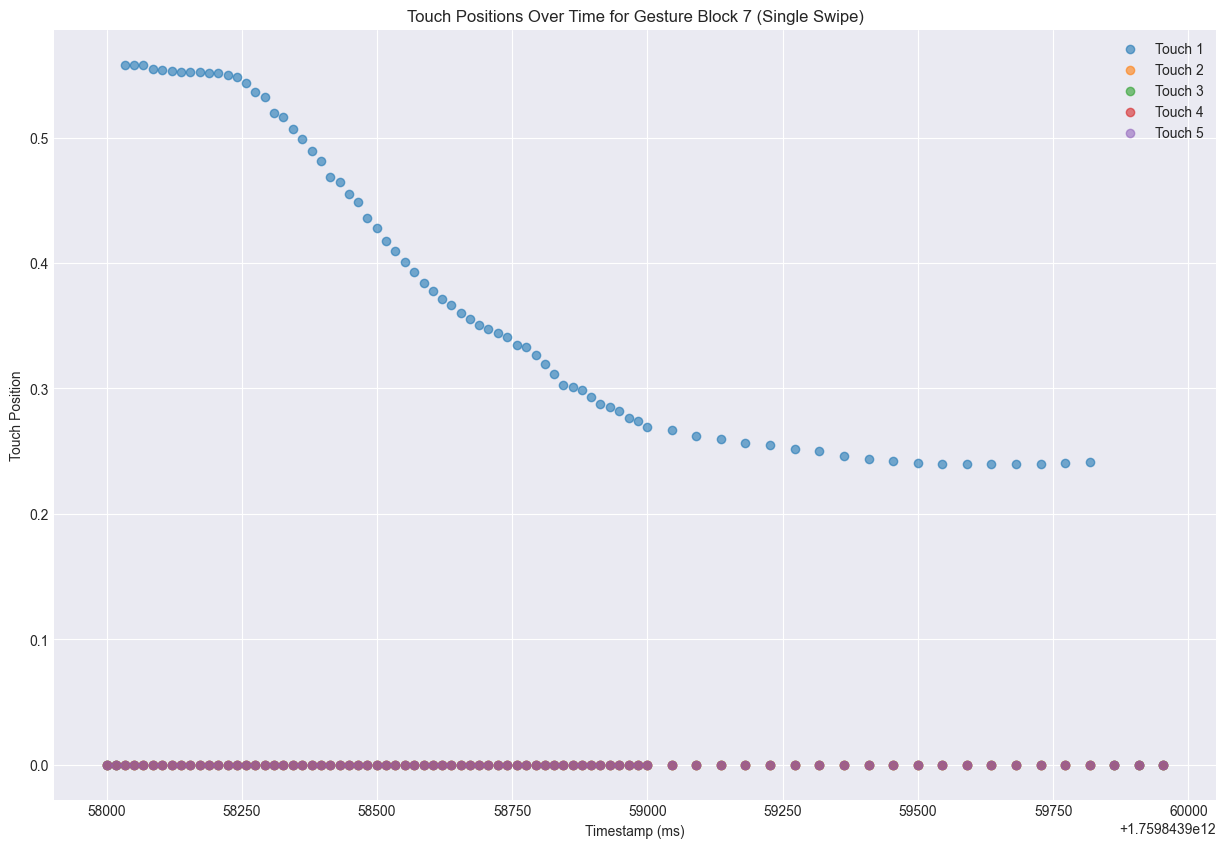

In [654]:
# draw a graph of the finger positions for the first gesture_block and title it with the parent_gesture

idx_tap_and_hold = np.where(df["gesture_block"].unique() == df[df[LABEL_COLUMN] == "Single Swipe"]["gesture_block"].iloc[1])[0][0]

plt.figure(figsize=(15, 10))
first_gesture_block = df["gesture_block"].unique()[idx_tap_and_hold]
gesture_block_df = df[df["gesture_block"] == first_gesture_block]
for touch_num in range(1, 6):
    plt.scatter(
        gesture_block_df["timestamp_ms"], 
        gesture_block_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Gesture Block {first_gesture_block} ({gesture_block_df[LABEL_COLUMN].iloc[0]})")
plt.legend()
plt.show()

In [655]:
# Print unique "gesture" column counts
print(df["gesture"].value_counts())

gesture
Pinch Swipe (Rechts)       135429
Pinch Swipe (Links)        117348
Spread Swipe (Rechts)      101535
Spread Swipe (Links)        88494
Single Swipe (3 Finger)     67956
Single Swipe (All Air)      59556
Name: count, dtype: int64


In [656]:
gesture_blocks = (
    df[df["is_gesture"] == 1]
    # df
    .groupby(["participant_id", "session_task_id", "group_id", "gesture_block"])
)
print(f"Total gesture blocks (excluding 'No Gesture'): {len(gesture_blocks)}")

Total gesture blocks (excluding 'No Gesture'): 6216


In [657]:
sequences = []   # list of arrays, each (T_i, D)
labels = []      # list of strings or ints
meta = []

for (pid, sid, group_id, gb), gdf in gesture_blocks:
    # Extract feature matrix for this gesture
    X_seq = gdf[feature_columns].to_numpy(dtype="float32")  # shape (T_i, D)
    if len(X_seq) == 0:
        continue

    sequences.append(X_seq)
    labels.append(gdf[LABEL_COLUMN].iloc[0])  # all rows in block share the same label
    meta.append({
        "group_id": group_id,
        "participant_id": pid,
        "session_task_id": sid,
        "gesture_block": gb,
        "num_samples": len(X_seq),
    })

In [658]:
# Print the number of sequences and unique labels
print(f"Extracted {len(sequences)} sequences with {len(set(labels))} unique labels.")
# Print the unique labels and their counts
label_counts = pd.Series(labels).value_counts()
print("Label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Extracted 6216 sequences with 3 unique labels.
Label counts:
  Pinch Swipe: 2163
  Single Swipe: 2037
  Spread Swipe: 2016


In [659]:
feature_columns

['num_moving_fingers',
 'dist_1_2',
 'dist_1_3',
 'dist_1_4',
 'dist_1_5',
 'dist_2_3',
 'dist_2_4',
 'dist_2_5',
 'dist_3_4',
 'dist_3_5',
 'dist_4_5',
 'touch_1_position_velocity',
 'touch_1_has_moved_longterm',
 'touch_2_position_velocity',
 'touch_2_has_moved_longterm',
 'touch_3_position_velocity',
 'touch_3_has_moved_longterm',
 'touch_4_position_velocity',
 'touch_4_has_moved_longterm',
 'touch_5_position_velocity',
 'touch_5_has_moved_longterm']

In [660]:
# Show the amount of "No Gesture" sequences, that sequence length is smaller or equal to the max length of the other gestures
no_gesture_lengths = [seq.shape[0] for seq, lab in zip(sequences, labels) if lab == "No Gesture"]
min_gesture_lengths = min(no_gesture_lengths) if no_gesture_lengths else 0
max_gesture_lengths = max(no_gesture_lengths) if no_gesture_lengths else 0
print(f"'No Gesture' sequences length: min={min_gesture_lengths}, max={max_gesture_lengths}")

gesture_lengths = [seq.shape[0] for seq, lab in zip(sequences, labels) if lab != "No Gesture"]
min_gesture_lengths = min(gesture_lengths) if gesture_lengths else 0
max_gesture_lengths = max(gesture_lengths) if gesture_lengths else 0
print(f"Gesture sequences length: min={min_gesture_lengths}, max={max_gesture_lengths}")

# Print all labels where the sequence length is greater than 500
long_gesture_labels = [lab for seq, lab in zip(sequences, labels) if seq.shape[0] > 500]
print(f"Labels with sequence length greater than 500: {set(long_gesture_labels)}")

# Draw a graph of all finger positions for the longest sequence that is not a "No Gesture"
max_length = 0
longest_seq = None
for seq, lab, met in zip(sequences, labels, meta):
    if lab != "No Gesture" and seq.shape[0] > max_length:
        max_length = seq.shape[0]
        longest_seq = (seq, lab, met)
if longest_seq:
    seq, lab, met = longest_seq

    # Print the session_task_id
    print(f"Longest sequence session_task_id: {met['session_task_id']}, gesture_block: {met['gesture_block']}, length: {seq.shape[0]}, label: {lab}, group_id: {met['group_id']}")

    # plt.figure(figsize=(15, 10))
    # time_axis = np.arange(seq.shape[0])
    # for touch_num in range(1, 6):
    #     plt.scatter(
    #         time_axis, 
    #         seq[:, feature_columns.index(f"touch_{touch_num}_position")], 
    #         label=f"Touch {touch_num}", 
    #         alpha=0.6
    #     )
    # plt.xlabel("Time Step")
    # plt.ylabel("Touch Position")
    # plt.title(f"Touch Positions Over Time for Longest Sequence ({lab})")
    # plt.legend()
    # plt.show()

'No Gesture' sequences length: min=0, max=0
Gesture sequences length: min=23, max=215
Labels with sequence length greater than 500: set()
Longest sequence session_task_id: f0f7a368-8be6-4b66-a7fd-15cf24663a74, gesture_block: 5573, length: 215, label: Pinch Swipe, group_id: 125b3c66-23e1-48a5-aa30-ad7f53466fad


In [661]:
# Count the number of sequences with No Gesture, that are longer than the max length of the other gestures
no_gesture_long_sequences = [
    (seq, lab) for seq, lab in zip(sequences, labels) 
    if lab == "No Gesture" and seq.shape[0] > max(gesture_lengths)
]
print(f"Number of 'No Gesture' sequences longer than max gesture length: {len(no_gesture_long_sequences)} leaving out {len(no_gesture_lengths) - len(no_gesture_long_sequences)} sequences.")

Number of 'No Gesture' sequences longer than max gesture length: 0 leaving out 0 sequences.


In [662]:
# Filter to only include sequences that are equal to or shorter than the max length of the other gestures
filtered_sequences = []
filtered_labels = []
filtered_meta = []
for seq, lab, meta in zip(sequences, labels, meta):
    if lab == "No Gesture" and seq.shape[0] > max(gesture_lengths):
        continue
    filtered_sequences.append(seq)
    filtered_labels.append(lab)
    filtered_meta.append(meta)
sequences = filtered_sequences
labels = filtered_labels
meta = filtered_meta

In [663]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(labels)           # shape (N,)
num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes)     # shape (N, num_classes)


In [664]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(seq.shape[0] for seq in sequences)  # e.g. 400
D = sequences[0].shape[1]

X_padded = pad_sequences(
    sequences,
    maxlen=max_len,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0      # padding value
)  # shape: (N, max_len, D)
X = X_padded

print(X.shape)


(6216, 215, 21)


In [665]:
# Draw a graph of the finger positions of the first entry in sequences
# plt.figure(figsize=(15, 10))
# first_sequence = sequences[0]
# for touch_num in range(1, 6):
#     plt.scatter(
#         range(first_sequence.shape[0]), 
#         first_sequence[:, feature_columns.index(f"touch_{touch_num}_position")], 
#         label=f"Touch {touch_num}", 
#         alpha=0.6
#     )
# plt.xlabel("Time Step")
# plt.ylabel("Touch Position")
# plt.title(f"Touch Positions Over Time for First Sequence ({labels[0]})")
# plt.legend()
# plt.show()

In [666]:
unique_participants = df['participant_id'].unique()
print(f"Unique participants: {unique_participants}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm0'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm1'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm10'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm11'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm12'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm13'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm14'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm15'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm16'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm17'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm18'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm19'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm2'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm3'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm4'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm5'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm6'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm7'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm8'
 '5d52daf3-c962-4db6-a8f8-298a0bb01733_perm9'
 '6331fbd

In [667]:
# Split participants into train, val, test sets
train_indices = [i for i, met in enumerate(meta) if met['participant_id'] in train_participants]
val_indices = [i for i, met in enumerate(meta) if met['participant_id'] in val_participants]
test_indices = [i for i, met in enumerate(meta) if met['participant_id'] in test_participants]
X_train, y_train = X[train_indices], y[train_indices]
X_val, y_val = X[val_indices], y[val_indices]
X_test, y_test = X[test_indices], y[test_indices]
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (3796, 215, 21), (3796, 3)
Validation set: (1215, 215, 21), (1215, 3)
Test set: (1205, 215, 21), (1205, 3)


In [668]:
# Draw a graph of the first test sequence window with the correct label in the title
# plt.figure(figsize=(15, 10))
# first_test_sequence = X_test[0]
# for touch_num in range(1, 6):
#     plt.scatter(
#         range(first_test_sequence.shape[0]), 
#         first_test_sequence[:, feature_columns.index(f"touch_{touch_num}_position")], 
#         label=f"Touch {touch_num}", 
#         alpha=0.6
#     )
# plt.xlabel("Time Step")
# plt.ylabel("Touch Position")
# plt.title(f"Touch Positions Over Time for First Test Sequence ({le.inverse_transform([np.argmax(y_test[0])])[0]})")
# plt.legend()
# plt.show()

In [669]:
# Per label, print the amount of samples in each split in one row
train_counts = pd.Series(np.argmax(y_train, axis=1)).value_counts().sort_index()
val_counts = pd.Series(np.argmax(y_val, axis=1)).value_counts().sort_index()
test_counts = pd.Series(np.argmax(y_test, axis=1)).value_counts().sort_index()
print("Label counts per split:")
for label_idx in range(num_classes):
    train_count = train_counts.get(label_idx, 0)
    val_count = val_counts.get(label_idx, 0)
    test_count = test_counts.get(label_idx, 0)
    label_name = le.classes_[label_idx]
    print(f"  {label_name}: Train={train_count}, Val={val_count}, Test={test_count}")

Label counts per split:
  Pinch Swipe: Train=1332, Val=424, Test=407
  Single Swipe: Train=1244, Val=397, Test=396
  Spread Swipe: Train=1220, Val=394, Test=402


In [670]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
# from tensorflow.keras.optimizers import Adam

# max_len = X_train.shape[1]
# D = X_train.shape[2]
# num_classes = y_train.shape[1]

# model = Sequential()

# # 1) Masking: ignore padded timesteps (value=0.0 from preprocessing)
# model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))

# model.add(LSTM(128, return_sequences=True))

# model.add(LSTM(64))

# model.add(Dropout(0.3))

# model.add(Dense(num_classes, activation="softmax"))

# optimizer = Adam(learning_rate=5e-4)
# model.compile(
#     loss="categorical_crossentropy",
#     optimizer=optimizer,
#     metrics=["accuracy"]
# )

# model.summary()

In [671]:
# Create a CNNLSTM model for gesture classification
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, Masking
from tensorflow.keras.optimizers import Adam

max_len = X_train.shape[1]
D = X_train.shape[2]
num_classes = y_train.shape[1]

# Create the CNNLSTM model, with 2 Conv1D layers, followed by MaxPooling, then an LSTM layer, and finally Dense layers
model = Sequential()
model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_10 (Masking)            │ (None, 215, 21)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 215, 128)       │        76,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,755 (526.39 KB)

 Trainable params: 134,755 (526.39 KB)

 Non-trainable params: 0 (0.00 B)

In [672]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

batch_size = 16     # optimization knob: [16, 32, 64]
epochs = 100        # upper limit; early stopping will cut it earlier

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 58s 235ms/step - accuracy: 0.5790 - loss: 0.8134 - val_accuracy: 0.6634 - val_loss: 0.6639
Epoch 2/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 50s 209ms/step - accuracy: 0.7297 - loss: 0.5669 - val_accuracy: 0.7514 - val_loss: 0.5279
Epoch 3/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 47s 199ms/step - accuracy: 0.7803 - loss: 0.4471 - val_accuracy: 0.8543 - val_loss: 0.3200
Epoch 4/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 47s 196ms/step - accuracy: 0.8704 - loss: 0.3221 - val_accuracy: 0.8790 - val_loss: 0.2883
Epoch 5/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 47s 197ms/step - accuracy: 0.9146 - loss: 0.2459 - val_accuracy: 0.8708 - val_loss: 0.3583
Epoch 6/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 46s 192ms/step - accuracy: 0.9318 - loss: 0.2074 - val_accuracy: 0.9062 - val_loss: 0.2202
Epoch 7/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step - accuracy: 0.9560 - loss: 0.1290 - val_accuracy: 0.9416 - val_loss: 0.1241
Epoch 8/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 43s 179ms/step - accuracy: 0.9708 -

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step


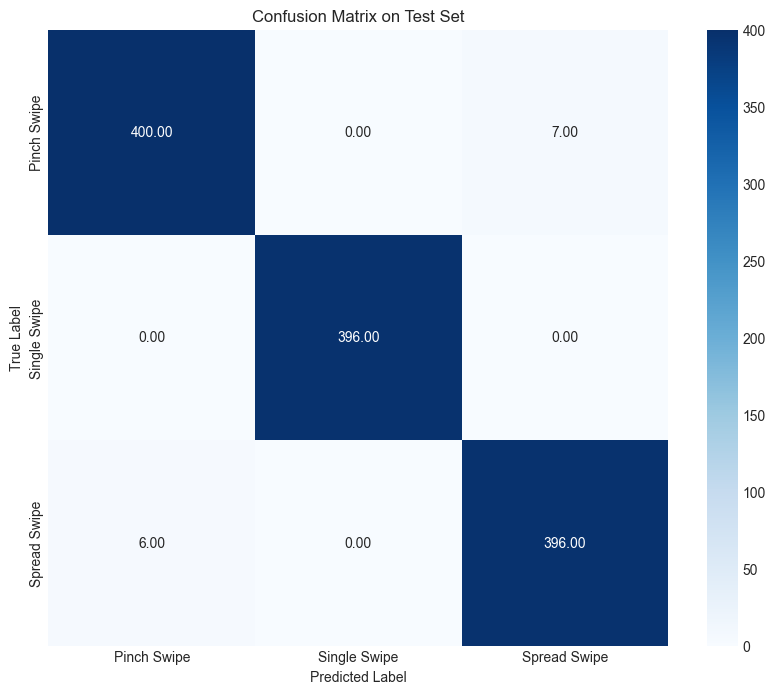

In [673]:
# Draw heatmap of confusion matrix for test set
from sklearn.metrics import confusion_matrix

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

## Test with Szenarios

In [674]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
-- WHERE is_gesture = 1 and marker_label != 'No Gesture'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None


In [675]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [676]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [677]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df[col] = szenarien_df[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df['motor_angle'] = szenarien_df.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [678]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
dtype: int64

In [679]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
No Gesture                        3235
Tap and Hold                      2479
Spread Swipe                      1723
Single Swipe                      1450
Pinch Swipe                        838
Two-Finger Tap                     553
Two-Finger Double Tap              516
Two-Finger Opposite Double Tap     486
Double Tap                         367
Two-Finger Opposite Tap            315
Name: count, dtype: int64


In [680]:
# Print count of unique session_tasks
print(f"Unique session_task_ids in Szenarien data: {szenarien_df['session_task_id'].nunique()}")

Unique session_task_ids in Szenarien data: 227


In [681]:
# Make feature_df
szenarien_feature_df, szenarien_additional_columns = create_feature_df(szenarien_df)
szenarien_feature_columns = get_column_names(szenarien_additional_columns)

In [682]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)

for sid, sdf in szenarien_feature_df.groupby("session_task_id"):
    X_stream = sdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    streams[sid] = X_stream
    streams_labels[sid] = y_stream

In [683]:
# Print number of streams
print(f"Extracted {len(streams)} streams from Szenarien data.")

Extracted 227 streams from Szenarien data.


In [684]:
max_len = 200
step_size = 20
threshold = 0.05             # gesture confidence; tune this

print(f"Using max_len={max_len}, threshold={threshold} for online prediction.")
touch_indices = [2, 5, 8, 11, 14]  # position columns for touch_1 to touch_5

# For debug purposes draw a graph of the finger positions for each window
def predict_stream_online(X_stream, y_stream):
    did_print = 0
    T, D = X_stream.shape
    preds = []
    pred_times = []
    real_labels = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        window_labels = y_stream[t_start:t_end]
        if not any(label.endswith("Swipe") for label in window_labels if label is not None):
            continue
        if window_labels[0] is not None or window_labels[-1] is not None:
            continue
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        y_window = y_stream[t_start:t_end]
        window = X_stream[t_start:t_end]

        # Get the correct label for this window (most common label in the window that ends with "Swipe")
        window_labels = [label for label in y_window if label is not None and label.endswith("Swipe")]
        if len(window_labels) == 0:
            continue
        most_common_label = pd.Series(window_labels).mode()[0]
        real_labels.append(most_common_label)
        
        # --- Model Prediction Logic ---
        window_batch = window[np.newaxis, ...]
        proba = model.predict(window_batch, verbose=0)[0]

        # print all probabilities for debug with label
        # for cls_idx, class_label in enumerate(le.classes_):
        #     ax.text(t_start, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]) * (cls_idx + 1), 
        #             f"{class_label}: {proba[cls_idx]:.2f}", fontsize=10, verticalalignment='bottom')

        cls_idx = np.argmax(proba)
        conf = proba[cls_idx]
        label = le.classes_[cls_idx] # if conf >= threshold else "No Gesture"

        # if label != most_common_label:
        #     print(f"Mismatch at t_start={t_start}: Predicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        #     for cls_idx_debug, class_label in enumerate(le.classes_):
        #         print(f"  {class_label}: {proba[cls_idx_debug]:.4f}")

        #     # Draw a graph of all finger positions
        #     plt.figure(figsize=(15, 10))
        #     time_axis = np.arange(window.shape[0])
        #     for touch_num in range(2, 6):
        #         plt.scatter(
        #             time_axis, 
        #             window[:, feature_columns.index(f"dist_1_{touch_num}")], 
        #             label=f"Touch {touch_num}", 
        #             alpha=0.6
        #         )
        #     plt.xlabel("Time Step")
        #     plt.ylabel("Touch Position")
        #     plt.title(f"Touch Positions Over Time for Window starting at {t_start}\nPredicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        #     plt.legend()
        #     plt.show()
        #     return
        # else:
        #     print(f"Match at t_start={t_start}: Predicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        
        # Add text info to the plot itself
        # ax.text(t_start, ax.get_ylim()[1], f"Pred: {label} ({conf:.2f})", 
        #         fontsize=12, fontweight='bold', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

        preds.append(label)
        pred_times.append(t_start)

        # did_print += 1
        # if did_print >= 5:
        #     break

    # plt.tight_layout()
    # plt.show()
    return np.array(preds), np.array(pred_times), np.array(real_labels)


Using max_len=200, threshold=0.05 for online prediction.


In [685]:
from sklearn.metrics import confusion_matrix, classification_report

all_true = []
all_pred = []

# print streams keys
did_it = 0
for sid, X_stream in streams.items():
    did_it += 1
    y_stream = streams_labels[sid] 
    preds, pred_times, real_labels = predict_stream_online(X_stream, y_stream)

    all_true.extend(real_labels)
    all_pred.extend(preds)

    # Print y_stream for those that are not none
    # print(f"True labels for stream {sid}:")
    # for i in range(len(y_stream)):
    #     if y_stream[i] is not None:
    #         print(f"  Index {i}: {y_stream[i]}")

    # if did_it >= 1:
    #     break


In [686]:
# Print the distribution of real labels and predicted labels
print("Real label distribution:")
real_label_counts = pd.Series(all_true).value_counts()
for label, count in real_label_counts.items():
    print(f"  {label}: {count}")
print("Predicted label distribution:")
pred_label_counts = pd.Series(all_pred).value_counts()
for label, count in pred_label_counts.items():
    print(f"  {label}: {count}")

Real label distribution:
  Single Swipe: 91
  Spread Swipe: 33
  Pinch Swipe: 5
Predicted label distribution:
  Single Swipe: 47
  Pinch Swipe: 43
  Spread Swipe: 39


In [687]:
# Print unique all_true and all_pred labels
all_true = np.array(all_true)
all_pred = np.array(all_pred)
# Replace None with "No Gesture" in all_true
all_true = np.array([label if label is not None and label != 'No Gesture' else "No Gesture" for label in all_true])
unique_true_labels = np.unique(all_true)
unique_pred_labels = np.unique(all_pred)
print(f"Unique true labels: ({len(unique_true_labels)}) {unique_true_labels}")
print(f"Unique predicted labels: ({len(unique_pred_labels)}) {unique_pred_labels}")

Unique true labels: (3) ['Pinch Swipe' 'Single Swipe' 'Spread Swipe']
Unique predicted labels: (3) ['Pinch Swipe' 'Single Swipe' 'Spread Swipe']


              precision    recall  f1-score   support

 Pinch Swipe       0.07      0.60      0.12         5
Single Swipe       1.00      0.52      0.68        91
Spread Swipe       0.69      0.82      0.75        33

    accuracy                           0.60       129
   macro avg       0.59      0.64      0.52       129
weighted avg       0.89      0.60      0.68       129



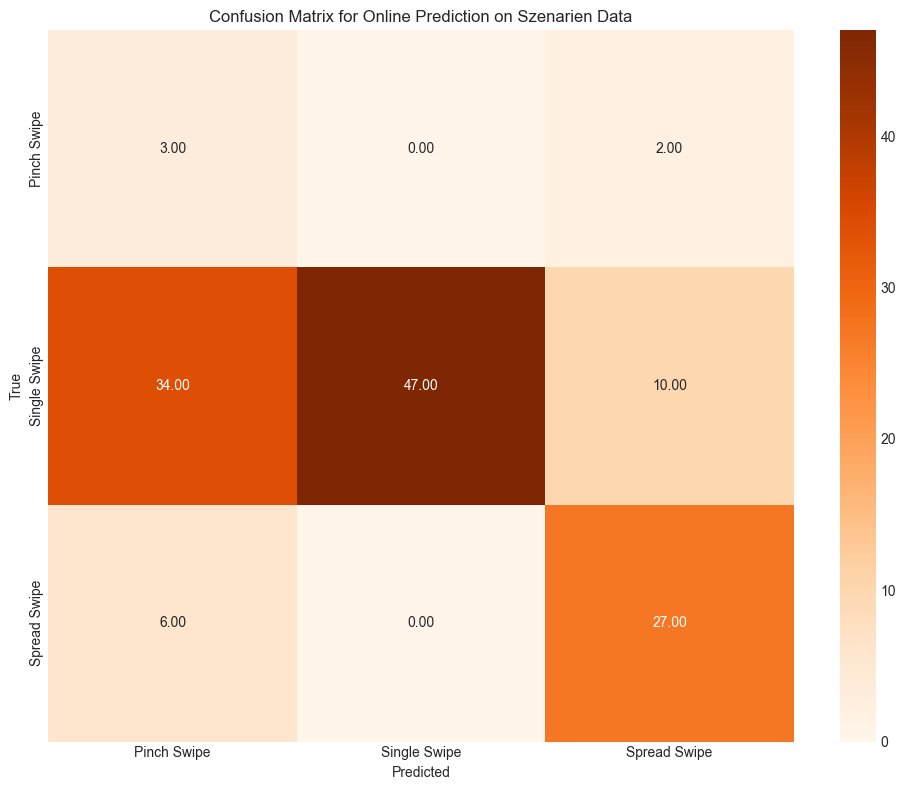

In [688]:
# Optionally restrict to known classes
# map string labels -> indices with same LabelEncoder if classes match
y_true_int = le.transform(all_true)           # if marker labels use same names
y_pred_int = le.transform(all_pred)

used_labels = np.unique(np.concatenate([y_true_int, y_pred_int]))
used_target_names = le.inverse_transform(used_labels)
print(
    classification_report(
        y_true_int,
        y_pred_int,
        labels=used_labels,
        target_names=used_target_names
    )
)

cm = confusion_matrix(y_true_int, y_pred_int, labels=range(len(le.classes_)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)   # convert NaNs (0/0) to 0

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Oranges"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Online Prediction on Szenarien Data")
plt.tight_layout()
plt.show()


In [689]:
# Test with szenarios, but give a whole marker_label group at once to check if the classification would work with the correct windowing strategy

# Put all group_ids in windows
windows = []
window_lables = []
window_meta = []
for gid, gdf in szenarien_feature_df.groupby("group_id"):
    # ignore if the marker_label is None or does not end with "Swipe"
    if gdf["marker_label"].iloc[0] is None or not gdf["marker_label"].iloc[0].endswith("Swipe"):
        continue
    X_window = gdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    windows.append(X_window)
    window_lables.append(gdf["marker_label"].iloc[0])
    window_meta.append({
        "session_task_id": gdf["session_task_id"].iloc[0],
        "participant_id": gdf["participant_id"].iloc[0],
        "group_id": gid
    })

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 50 windows from Szenarien data for group_id prediction.


In [690]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=20, max=199
Window label counts:
  Single Swipe: 25
  Spread Swipe: 18
  Pinch Swipe: 7


In [691]:
# Predict each window
all_window_true = []
all_window_pred = []

for X_window, true_label in zip(windows, window_lables):
    T, D = X_window.shape
    # if T < max_len:
    #     # Pad if too short
    #     X_padded = np.pad(
    #         X_window,
    #         ((0, max_len - T), (0, 0)),
    #         mode="constant",
    #         constant_values=-1.0
    #     )
    # else:
    #     # Truncate if too long
    #     X_padded = X_window[:max_len, :]

    X_batch = X_window[np.newaxis, ...]  # (1, max_len, D)
    proba = model.predict(X_batch, verbose=0)[0]
    
    cls_idx = np.argmax(proba)
    conf = proba[cls_idx]
    pred_label = le.classes_[cls_idx] if conf >= threshold else "No Gesture"

    all_window_true.append(true_label)
    all_window_pred.append(pred_label)
# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
unique_window_true_labels = np.unique(all_window_true)
unique_window_pred_labels = np.unique(all_window_pred)
print(f"Unique true window labels: ({len(unique_window_true_labels)}) {unique_window_true_labels}")
print(f"Unique predicted window labels: ({len(unique_window_pred_labels)}) {unique_window_pred_labels}")

Unique true window labels: (3) ['Pinch Swipe' 'Single Swipe' 'Spread Swipe']
Unique predicted window labels: (3) ['Pinch Swipe' 'Single Swipe' 'Spread Swipe']


In [1]:
# Print confusion matrix and classification report for window predictions
y_window_true_int = le.transform(all_window_true)           # if marker labels use same names
y_window_pred_int = le.transform(all_window_pred)

used_labels_window = np.unique(np.concatenate([y_window_true_int, y_window_pred_int]))
used_target_names_window = le.inverse_transform(used_labels_window)
print(
    classification_report(
        y_window_true_int,
        y_window_pred_int,
        labels=used_labels_window,
        target_names=used_target_names_window
    )
)

cm_window = confusion_matrix(y_window_true_int, y_window_pred_int, labels=range(len(le.classes_)))
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1, keepdims=True)
cm_window_norm = np.nan_to_num(cm_window_norm)   # convert NaNs (0/0) to 0

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Whole Window Prediction on Szenarien Data")
plt.tight_layout()
plt.show()

NameError: name 'le' is not defined

In [693]:
import winsound

winsound.MessageBeep()  # system default sound